c:\Users\SHIVAM SHARMA\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\SHIVAM SHARMA\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
c:\Users\SHIVAM SHARMA\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\SHIVAM SHARMA\AppData\Local\Programs\Python\Python313\Lib\site-

0 [D loss: 0.987047 | D accuracy: 23.83] [G loss: 0.922065]


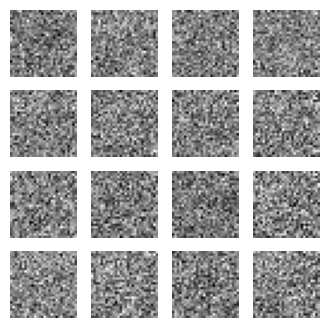

1000 [D loss: 4.361609 | D accuracy: 2.02] [G loss: 0.005486]


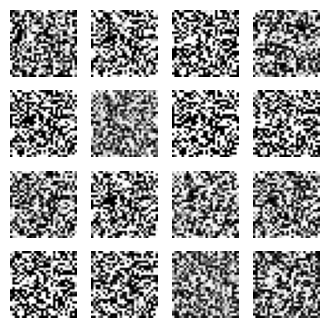

2000 [D loss: 4.817826 | D accuracy: 1.98] [G loss: 0.002792]


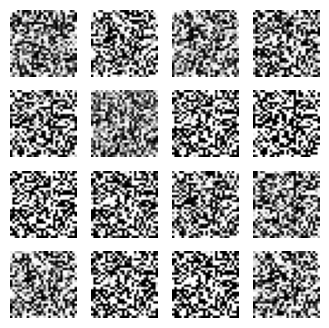

3000 [D loss: 5.084220 | D accuracy: 1.97] [G loss: 0.001879]


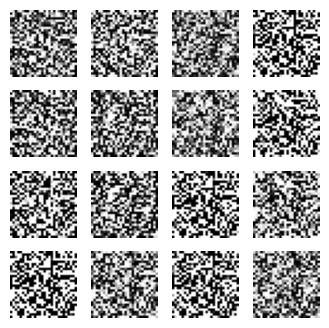

4000 [D loss: 5.274751 | D accuracy: 1.96] [G loss: 0.001418]


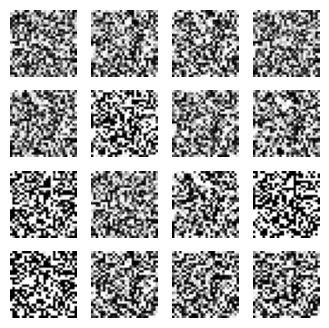

5000 [D loss: 5.430106 | D accuracy: 1.96] [G loss: 0.001140]


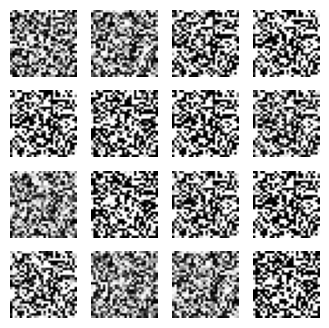

6000 [D loss: 5.571162 | D accuracy: 1.96] [G loss: 0.000952]


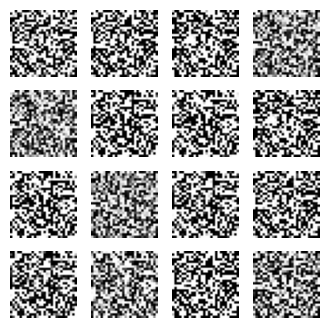

7000 [D loss: 5.711872 | D accuracy: 1.96] [G loss: 0.000818]


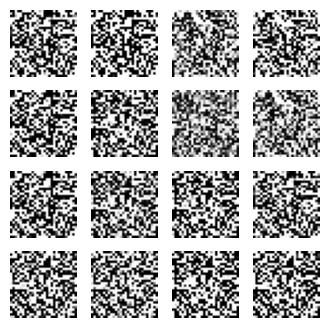

8000 [D loss: 5.860058 | D accuracy: 1.96] [G loss: 0.000716]


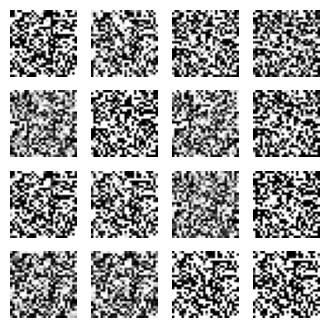

9000 [D loss: 6.011052 | D accuracy: 1.96] [G loss: 0.000637]


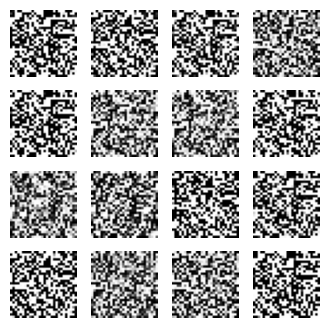

In [4]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Dense, Flatten, Reshape, LeakyReLU, BatchNormalization
from tensorflow.keras.models import Sequential
import matplotlib.pyplot as plt

# Load the MNIST dataset
(X_train, _), (_, _) = mnist.load_data()

# Normalize the images to the range [-1, 1]
X_train = (X_train.astype(np.float32) - 127.5) / 127.5
X_train = np.expand_dims(X_train, axis=-1)

# Build the generator model
def build_generator():
    model = Sequential()
    model.add(Dense(256, input_dim=100))
    model.add(LeakyReLU(alpha=0.2))
    model.add(BatchNormalization(momentum=0.8))
    model.add(Dense(512))
    model.add(LeakyReLU(alpha=0.2))
    model.add(BatchNormalization(momentum=0.8))
    model.add(Dense(1024))
    model.add(LeakyReLU(alpha=0.2))
    model.add(BatchNormalization(momentum=0.8))
    model.add(Dense(28 * 28 * 1, activation='tanh'))
    model.add(Reshape((28, 28, 1)))
    return model

# Build the discriminator model
def build_discriminator():
    model = Sequential()
    model.add(Flatten(input_shape=(28, 28, 1)))
    model.add(Dense(512))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dense(256))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dense(1, activation='sigmoid'))
    return model

# Compile the discriminator
discriminator = build_discriminator()
discriminator.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Build the GAN
def build_gan(generator, discriminator):
    model = Sequential()
    model.add(generator)
    discriminator.trainable = False
    model.add(discriminator)
    return model

# Compile the GAN
generator = build_generator()
gan = build_gan(generator, discriminator)
gan.compile(loss='binary_crossentropy', optimizer='adam')

# --- CORRECTED: sample_images function defined BEFORE its call in the loop ---
def sample_images(generator, image_grid_rows=4, image_grid_columns=4):
    # Generate random noise
    noise = np.random.normal(0, 1, (image_grid_rows * image_grid_columns, 100))
    # Generate images from the generator
    # Use verbose=0 to prevent TensorFlow from printing progress every time
    generated_images = generator.predict(noise, verbose=0) 
    # Rescale images from tanh output [-1, 1] to display range [0, 1]
    generated_images = 0.5 * generated_images + 0.5

    # Plot the images in a grid
    fig, axs = plt.subplots(image_grid_rows, image_grid_columns, figsize=(4, 4), sharey=True, sharex=True)
    cnt = 0
    for i in range(image_grid_rows):
        for j in range(image_grid_columns):
            axs[i, j].imshow(generated_images[cnt, :, :, 0], cmap='gray')
            axs[i, j].axis('off')
            cnt += 1
    # This command opens the image window
    plt.show() 
# -----------------------------------------------------------------------------

# Train the GAN
epochs = 10000
batch_size = 64
sample_interval = 1000

real = np.ones((batch_size, 1))
fake = np.zeros((batch_size, 1))

for epoch in range(epochs):

    # Train the discriminator
    idx = np.random.randint(0, X_train.shape[0], batch_size)
    real_images = X_train[idx]
    
    noise = np.random.normal(0, 1, (batch_size, 100))
    generated_images = generator.predict(noise, verbose=0) # suppress prediction output

    d_loss_real = discriminator.train_on_batch(real_images, real)
    d_loss_fake = discriminator.train_on_batch(generated_images, fake)
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

    # Train the generator
    noise = np.random.normal(0, 1, (batch_size, 100))
    g_loss = gan.train_on_batch(noise, real)

    # Print the progress and show images
    if epoch % sample_interval == 0:
        print(f"{epoch} [D loss: {d_loss[0]:.6f} | D accuracy: {100*d_loss[1]:.2f}] [G loss: {g_loss:.6f}]")
        sample_images(generator) # This now calls the correct function